# <center>Clustering of titles</center>
---

This code aims to cluster the titles of YouTube videos, trying to search for videos related to politics

In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
from langdetect import detect, DetectorFactory
from multiprocessing import Pool, cpu_count
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

nltk.download("stopwords")
stop_words = stopwords.words("english")

vectorizer = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),   # unigrams + bigrams (captura combinações de palavras)
    max_features=5000     # limita vocabulário para economizar memória
)

[nltk_data] Downloading package stopwords to /home/ester/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
df_en = pd.read_csv("../data/preprocessed_english_titles.csv")
display(df_en)

,Unnamed: 0,video_id,title,youtube_video_link,clean_text
0,0,BFQ8gqvkjz8,nasthug | Boiler Room Tokyo: Tohji Presents u-ha,https://www.youtube.com/watch?v=BFQ8gqvkjz8,nasthug boiler room tokyo tohji present
1,1,X928ajAsdMM,Puddle Of Mudd - Livin' On Borrowed Time (Offi...,https://www.youtube.com/watch?v=X928ajAsdMM,puddle mudd livin borrow time official audio
2,2,PWbMXDvviTw,The Titans: Rise of the Unstoppable,https://www.youtube.com/watch?v=PWbMXDvviTw,titans rise unstoppable
3,3,o62RwF_s4Jw,'Rabbi' Shmuley: a walking antisemitic stereotype,https://www.youtube.com/watch?v=o62RwF_s4Jw,rabbi shmuley walk antisemitic stereotype
4,4,QJWplEkDyck,What Just Happened On Our Earth!!! September 2...,https://www.youtube.com/watch?v=QJWplEkDyck,happen earth september naturaldisaster
...,...,...,...,...,...
257054,257054,cl1QZWF6e_E,Utter Silence Is Fragile,https://www.youtube.com/watch?v=cl1QZWF6e_E,utter silence fragile
257055,257055,cgKtKsefXyQ,Willy Deville - Just Your Friends,https://www.youtube.com/watch?v=cgKtKsefXyQ,willy deville friend
257056,257056,6qO4TxA7U3c,Putin's Missiles 'Hit' NATO Nation's Train Car...,https://www.youtube.com/watch?v=6qO4TxA7U3c,putin missile nato nation train carry atacms s...
257057,257057,ojLpPQiFguE,"Stop the ""Moonlighting"" Bill. Tharman to Resig...",https://www.youtube.com/watch?v=ojLpPQiFguE,stop moonlighting bill tharman resign online z...


Melhor valor de K encontrado pela 2ª derivada: K = 7
Primeira Derivada: [-3.12833521e-04 -2.62050294e-04 -2.26507678e-04 -9.11278680e-05
 -3.16643085e-05 -2.91279940e-04 -4.05765029e-04 -2.24843158e-04
 -9.04158441e-05 -1.48297760e-04 -1.49822747e-04 -1.93614438e-04
 -2.05975606e-04 -1.43678196e-04 -1.85038021e-04 -1.40968355e-04
 -8.44609065e-05 -8.04137841e-05]
Segunda Derivada: [ 5.07832268e-05  4.31629213e-05  8.54612131e-05  9.74216849e-05
 -1.00076036e-04 -1.87050360e-04  3.32183914e-05  1.57674592e-04
  3.82726988e-05 -2.97034514e-05 -2.26583390e-05 -2.80764296e-05
  2.49681208e-05  1.04687924e-05  1.35492089e-06  5.02885574e-05
  3.02772852e-05  4.04712238e-06]


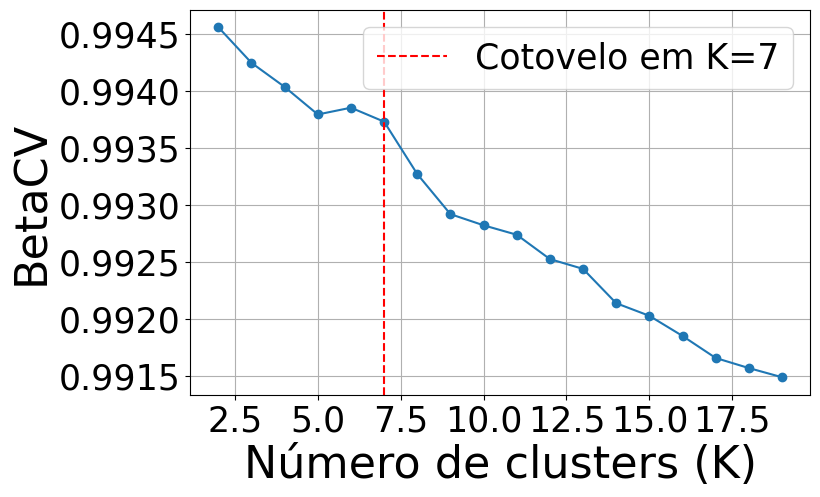

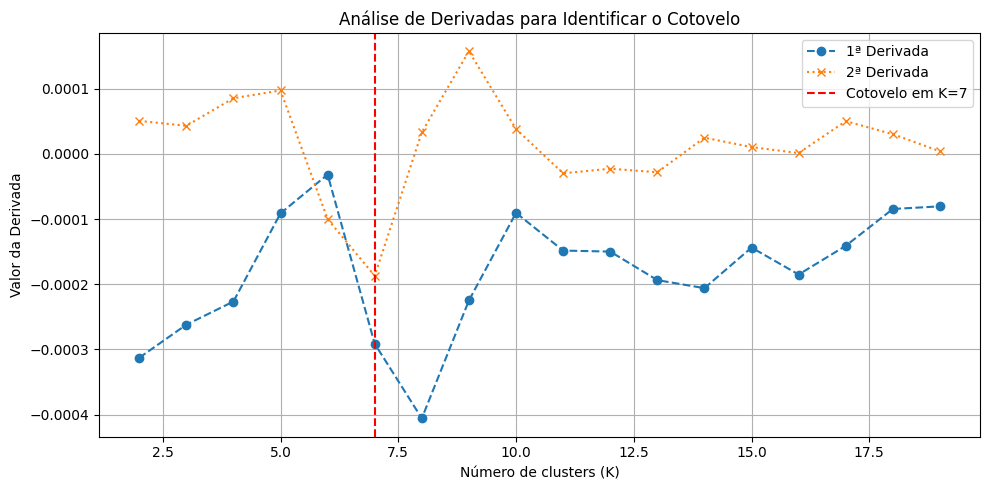

In [11]:
df_sample = df_en.sample(10000, random_state=42)
df_sample = df_sample.dropna(subset=["clean_text"])
X_tfidf = vectorizer.fit_transform(df_sample["clean_text"])

# Definição da função BetaCV (avalia a qualidade de um agrupamento; quanto menor, melhor)
def beta_cv(X, labels):
    distances = pairwise_distances(X) # DIstancia entre todos os pontos
    n = len(labels) # Número de amostras 
    
    # Soma das distâncias dentro de um cluster
    def intra_cluster_distance(dist_row, labels, idx):
        same_cluster = labels == labels[idx]
        same_cluster[idx] = False
        return np.sum(dist_row[same_cluster])

    # Soma das distâncias para pontos em outro cluster
    def inter_cluster_distance(dist_row, labels, idx):
        other_cluster = labels != labels[idx]
        return np.sum(dist_row[other_cluster])

    # Calcula as somas intra e inter para cada ponto
    A = np.array([intra_cluster_distance(distances[i], labels, i) for i in range(n)])
    B = np.array([inter_cluster_distance(distances[i], labels, i) for i in range(n)])

    a = np.sum(A) # Soma total intra-cluster
    b = np.sum(B) # Soma total inter-cluster

    # Conta os membros de cada cluster
    labels_unq = np.unique(labels)
    members = np.array([(labels == lbl).sum() for lbl in labels_unq])

    # Número total de pares intra-cluster possíveis
    N_in = np.array([m * (m - 1) for m in members])
    n_in = np.sum(N_in)

    # Número total de pares inter-cluster possíveis
    N_out = np.array([m * (n - m) for m in members])
    n_out = np.sum(N_out)

    # Cálculo do índice BetaCV
    beta_cv_value = (a / n_in) / (b / n_out)

    return beta_cv_value


# 2. Rodar KMeans para vários valores de K e calcular BetaCV
k_values = range(2, 20)
betacv_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_tfidf)
    score = beta_cv(X_tfidf, labels)
    betacv_scores.append(score)

# Derivadas numéricas (usando diferenças finitas)
first_derivative = np.gradient(betacv_scores)
second_derivative = np.gradient(first_derivative)

# O ponto de cotovelo pode ser aquele com maior curvatura (mínimo da segunda derivada)
knee_index = np.argmin(second_derivative)
melhor_k = k_values[knee_index]

print(f"Melhor valor de K encontrado pela 2ª derivada: K = {melhor_k}")
print(f"Primeira Derivada: {first_derivative}")
print(f"Segunda Derivada: {second_derivative}")

# PLot do Método do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(k_values, betacv_scores, marker='o')
plt.axvline(melhor_k, color='red', linestyle='--', label=f'Cotovelo em K={melhor_k}')
plt.xlabel('Número de clusters (K)', fontsize=32)
plt.ylabel('BetaCV', fontsize=32)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.grid(True)
plt.show()

# --- Plot 2: Derivadas ---
plt.figure(figsize=(10, 5))
plt.plot(k_values, first_derivative, label='1ª Derivada', marker='o', linestyle='--')
plt.plot(k_values, second_derivative, label='2ª Derivada', marker='x', linestyle=':')
plt.axvline(melhor_k, color='red', linestyle='--', label=f'Cotovelo em K={melhor_k}')
plt.title('Análise de Derivadas para Identificar o Cotovelo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Valor da Derivada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


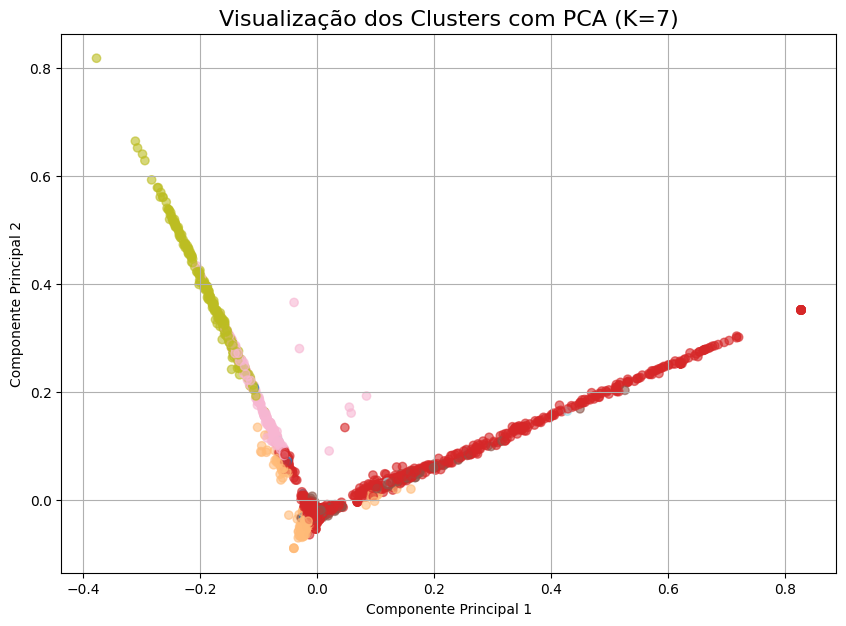

Cluster 0: 83 pontos
Cluster 1: 567 pontos
Cluster 2: 8466 pontos
Cluster 3: 198 pontos
Cluster 4: 254 pontos
Cluster 5: 299 pontos
Cluster 6: 99 pontos


In [12]:
from sklearn.decomposition import PCA

# 1. Defina o número de clusters
#k = 20 # ou use melhor_k, se tiver definido anteriormente


# 2. Aplique KMeans com o K escolhido
kmeans = KMeans(n_clusters=melhor_k, random_state=42)
labels = kmeans.fit_predict(X_tfidf)

# 3. Reduza para 2 dimensões usando PCA para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())

# 4. Plote os clusters em 2D
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab20", alpha=0.6)
plt.title(f"Visualização dos Clusters com PCA (K={melhor_k})", fontsize=16)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# labels contém o cluster atribuído a cada ponto
counts = np.bincount(labels)
df_sample["cluster"] = labels

# Printar o número de pontos em cada cluster
for cluster_id, count in enumerate(counts):
    print(f"Cluster {cluster_id}: {count} pontos")


In [14]:
# Adicionar os labels ao dataframe
df_sample["cluster"] = labels

# Mostrar exemplos de cada cluster
for c in range(melhor_k):
    cluster_videos = df_sample[df_sample["cluster"] == c]["clean_text"]
    n_videos = len(cluster_videos)
    exemplos = cluster_videos.head(15).tolist()  # 5 exemplos
    print(f"\nCluster {c} ({n_videos} vídeos):")
    for ex in exemplos:
        print("  -", ex)



Cluster 0 (83 vídeos):
  - battalion miss world historic documentary world weird
  - kate middleton miss princess smokescreen privacy
  - female channel personality charge crime grant suppression order
  - theraphi human charge station
  - peter doocy biden inadequate response maui wildfires gone miss
  - miss architect feat current
  - china boost defense budget change word taiwan china focus
  - discover miss hide predator compound
  - feel lost lazy unmotivated life watch tony robbin motivation
  - stop cycle generational tony evans sermon
  - moscow terror gunman carry crocus city hall carnage charge
  - tucker carlson putin global search miss news identitty politic
  - want miss total solar eclipse eclipse timeline viewing
  - tony shaffer ukraine
  - expert trump charge document biden

Cluster 1 (567 vídeos):
  - trump contro tutti mazzucco live puntata
  - blind justice trump trial jury newsmax daily
  - devin nune trump communication incidentally collect intelligence agency ne